In [ ]:
%matplotlib ipympl

In [1]:
import matplotlib.pyplot as plt
import numpy as np

### Load Simulation Data

In [2]:
t0 = np.load("../data/fig2/experiment_results.npy", allow_pickle=True).item()
pert = np.load("../data/fig2/relearning_results.npy", allow_pickle=True).item()

In [6]:
t0.keys()

dict_keys(['params', 'stimulus', 'target', 'stabilizing', 'manifold', 'decoding'])

In [8]:
og_manifold = t0["manifold"]["activity2"]
og_trial_order = t0["manifold"]["order"]
omp_manifold = pert["manifold"]["within"]["activity"].reshape(50, -1, 800)
omp_trial_order = pert["manifold"]["within"]["order"]
wmp_manifold = pert["manifold"]["outside"]["activity"].reshape(50, -1, 800)
wmp_trial_order = pert["manifold"]["outside"]["order"]

In [11]:
manifold = {
  "original": {
      "activity": og_manifold,
      "order": og_trial_order
    },
  "within": {
      "activity": omp_manifold,
      "order": omp_trial_order
    },
  "outside": {
      "activity": wmp_manifold,
      "order": wmp_trial_order
    }
}

In [34]:
n_targets = 4
target = 0 # 0-6
neuron_idx = 1

### Neuron Activity Range

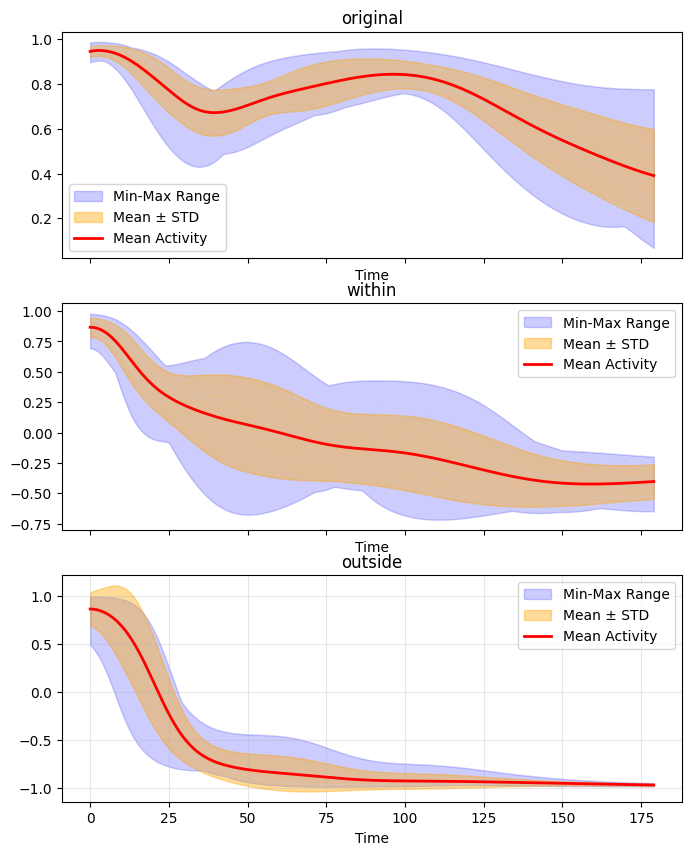

In [ ]:
og_activity = og_manifold[og_trial_order == target, :, neuron_idx]
omp_activity = omp_manifold[omp_trial_order == target, :, neuron_idx]
wmp_activity = wmp_manifold[wmp_trial_order == target, :, neuron_idx]

fig, axs = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

timesteps = np.arange(180)
for i, (activity, phase) in enumerate(zip([og_activity, omp_activity, wmp_activity], ["original", "within", "outside"])):
  ax = axs[i]
  ax.set_title(f"{phase}")
  mean_activity = np.mean(activity, axis=0)
  std_activity = np.std(activity, axis=0)
  min_activity = np.min(activity, axis=0)
  max_activity = np.max(activity, axis=0)

  # Plot individual trials (light gray)
  for trial in range(activity.shape[0]):
      ax.plot(timesteps, activity[trial, :], 'lightgray', alpha=0.3, linewidth=0.5)

  # Plot statistics
  ax.fill_between(timesteps, min_activity, max_activity, alpha=0.2, color='blue', label='Min-Max Range')
  ax.fill_between(timesteps, mean_activity - std_activity, mean_activity + std_activity, 
                    alpha=0.4, color='orange', label='Mean ± STD')
  ax.plot(timesteps, mean_activity, 'red', linewidth=2, label='Mean Activity')

  ax.set_xlabel('Time')
  ax.set_label('Neural Activity')
  ax.legend()

plt.grid(True, alpha=0.3)
plt.show()

### Tuning Curve

In [35]:
def tuning_curve(neuron_idx):
  """
  Plot the tuning curves for a given neuron index.
  """
  fig, axs = plt.subplots(3, 1, figsize=(8, 10), sharex=True, dpi=200)
  cm = plt.get_cmap("Set2", n_targets)
  for i,  phase in enumerate(["original", "within", "outside"]):
    ax = axs[i]
    trial_order = manifold[phase]["order"]
    activity = manifold[phase]["activity"]
    for target_idx in range(n_targets):
      mean_activity = np.mean(activity[trial_order == target_idx, :, neuron_idx], axis=0)
      ax.plot(timesteps, mean_activity, label=f"Target {target_idx}", linewidth=2, color=cm(target_idx))
    ax.set_xlabel("Time")
    ax.set_ylabel(f"Activation (Phase:{phase})")
  return fig, axs

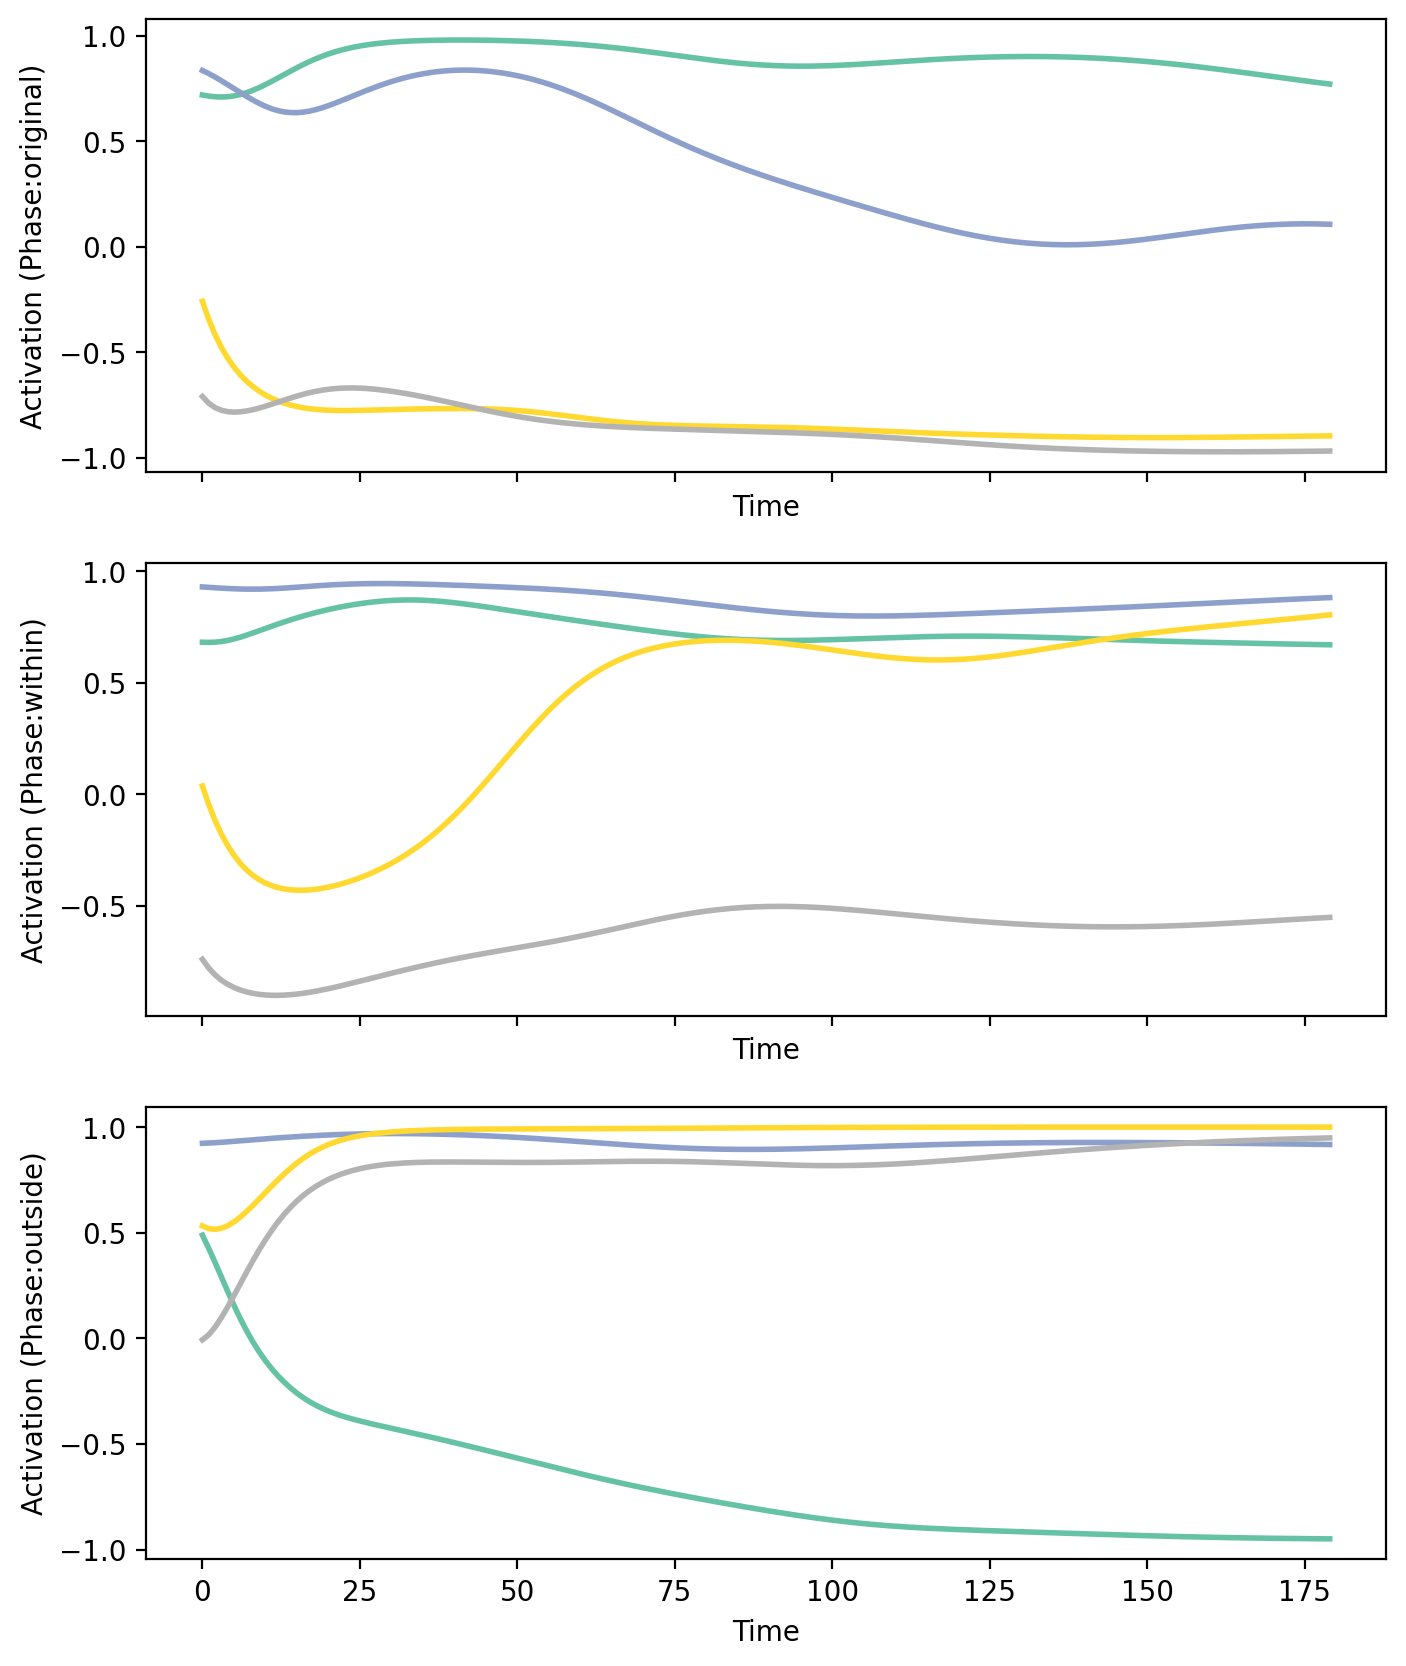

In [37]:
neuron_idx = 0
fig, axs = tuning_curve(neuron_idx)
fig.savefig(f"./turning_curve_{neuron_idx}.png", dpi=300)